# Phase 5 — XGBoost Training & Evaluation
**Project:** Jijiga Flood & Drought Risk Prediction  
**Weeks 13–14** | Input: `feature_matrix.parquet`

This notebook trains **8 XGBoost multiclass classifiers** (2 hazards × 4 horizons),
evaluates them with walk-forward cross-validation and a held-out test set (2023–2025),
runs SHAP feature importance, and builds the three-way comparison table.

| Model | Hazard | Horizon |
|-------|--------|---------|
| 1 | Drought | +1 day |
| 2 | Drought | +3 days |
| 3 | Drought | +7 days |
| 4 | Drought | +14 days |
| 5 | Flood | +1 day |
| 6 | Flood | +3 days |
| 7 | Flood | +7 days |
| 8 | Flood | +14 days |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, recall_score, confusion_matrix, classification_report
import shap
import json, os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

DATA_PATH     = '../src/data/processed/feature_matrix.parquet'
BASELINE_PATH = '../src/data/processed/baseline_scores.csv'
MODEL_DIR     = '../src/data/processed/xgb_models'
os.makedirs(MODEL_DIR, exist_ok=True)

FEATURE_VARS = ['spei_6', 'api_92', 'smi_fc', 'total_ro', 'tp', 't2m', 'e', 'pev']
LAGS         = [1, 3, 7, 14, 365]
HORIZONS     = [1, 3, 7, 14]
FEATURE_COLS = [f'{v}_lag_{l}' for v in FEATURE_VARS for l in LAGS]
N_CLASSES    = 4
LABEL_MAP    = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}
COLORS4      = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

WF_FOLDS = [
    {'train': (2001, 2014), 'val': (2015, 2016)},
    {'train': (2001, 2016), 'val': (2017, 2018)},
    {'train': (2001, 2018), 'val': (2019, 2020)},
]

PARAM_GRID = [
    {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 6, 'learning_rate': 0.01, 'n_estimators': 500},
    {'max_depth': 8, 'learning_rate': 0.05, 'n_estimators': 200},
    {'max_depth': 4, 'learning_rate': 0.10, 'n_estimators': 200},
]

In [ ]:
df = pd.read_parquet(DATA_PATH)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

print(f'Feature matrix: {df.shape}')
print(f'Train rows: {(df.time.dt.year <= 2022).sum()}')
print(f'Test  rows: {(df.time.dt.year >= 2023).sum()}')
print(f'Feature columns: {len(FEATURE_COLS)}')

# Naive persistence baseline — macro recall on test set
test_mask = df['time'].dt.year >= 2023
baseline_recall = {}
for hazard in ['drought', 'flood']:
    for n in HORIZONS:
        target  = f'{hazard}_risk_t_plus_{n}'
        current = f'{hazard}_risk'
        sub = df[test_mask].dropna(subset=[target, current])
        y_true = sub[target].astype(int)
        y_pred = sub[current].astype(int)
        baseline_recall[target] = round(
            recall_score(y_true, y_pred, average='macro', zero_division=0), 4
        )

print('\nBaseline macro recall (naive persistence, test set):')
for k, v in baseline_recall.items():
    print(f'  {k:<30}: {v:.4f}')

---
## Week 13 — Training with Walk-Forward CV & Hyperparameter Tuning

In [ ]:
# ── Helper functions ──────────────────────────────────────────────────────────
def sample_weights(y: np.ndarray, n_classes: int = N_CLASSES) -> np.ndarray:
    """Class-balanced weights: total / (n_classes * count_of_class)."""
    counts = np.bincount(y, minlength=n_classes)
    w = len(y) / (n_classes * np.maximum(counts, 1).astype(float))
    return w[y]

def walk_forward_cv(X_arr, y_arr, times, folds, params, n_classes=N_CLASSES):
    """Run 3-fold walk-forward CV; return mean and std macro recall."""
    scores = []
    for fold in folds:
        tr = (times.dt.year >= fold['train'][0]) & (times.dt.year <= fold['train'][1])
        va = (times.dt.year >= fold['val'][0])   & (times.dt.year <= fold['val'][1])
        X_tr, y_tr = X_arr[tr.values], y_arr[tr.values]
        X_va, y_va = X_arr[va.values], y_arr[va.values]
        if len(X_tr) == 0 or len(X_va) == 0:
            continue
        sw = sample_weights(y_tr, n_classes)
        m = XGBClassifier(**params, objective='multi:softmax', num_class=n_classes,
                          eval_metric='mlogloss', random_state=42,
                          n_jobs=-1, verbosity=0)
        m.fit(X_tr, y_tr, sample_weight=sw)
        y_pred = m.predict(X_va)
        scores.append(recall_score(y_va, y_pred, average='macro', zero_division=0))
    return (np.mean(scores), np.std(scores)) if scores else (0.0, 0.0)

def tune_and_train(target: str, df: pd.DataFrame, param_grid, folds, feature_cols):
    """Hyperparameter search on walk-forward folds, then refit on full training set."""
    valid    = df[target].notna()
    X_all    = df.loc[valid, feature_cols].values
    y_all    = df.loc[valid, target].values.astype(int)
    t_all    = df.loc[valid, 'time'].reset_index(drop=True)

    best_params, best_mean = param_grid[0], -1.0
    cv_log = []
    for params in param_grid:
        mean_r, std_r = walk_forward_cv(X_all, y_all, t_all, folds, params)
        cv_log.append({**params, 'cv_mean': mean_r, 'cv_std': std_r})
        if mean_r > best_mean:
            best_mean, best_params = mean_r, params

    best_std = [r['cv_std'] for r in cv_log if r['cv_mean'] == best_mean][0]

    # Final refit on complete training set (2001–2022)
    tr_mask = t_all.dt.year <= 2022
    X_tr, y_tr = X_all[tr_mask.values], y_all[tr_mask.values]
    sw = sample_weights(y_tr)
    final = XGBClassifier(**best_params, objective='multi:softmax', num_class=N_CLASSES,
                          eval_metric='mlogloss', random_state=42,
                          n_jobs=-1, verbosity=0)
    final.fit(X_tr, y_tr, sample_weight=sw)

    # Test evaluation — macro recall (consistent with CV metric)
    te_mask = t_all.dt.year >= 2023
    X_te, y_te = X_all[te_mask.values], y_all[te_mask.values]
    y_pred = final.predict(X_te)
    test_recall = recall_score(y_te, y_pred, average='macro', zero_division=0)

    return {
        'model':         final,
        'best_params':   best_params,
        'cv_mean':       round(best_mean, 4),
        'cv_std':        round(best_std, 4),
        'test_recall':   round(test_recall, 4),
        'y_true':        y_te,
        'y_pred':        y_pred,
        'X_test':        X_te,
        'cv_log':        cv_log,
    }

print('Helper functions defined.')

In [ ]:
# ── Train all 8 models ────────────────────────────────────────────────────────
results = {}

print(f'{"Model":<25} {"Best params":<45} {"CV Recall":>10} {"Test Recall":>12}')
print('-' * 96)

for hazard in ['drought', 'flood']:
    for n in HORIZONS:
        target   = f'{hazard}_risk_t_plus_{n}'
        task_key = f'{hazard}_+{n}d'

        res = tune_and_train(target, df, PARAM_GRID, WF_FOLDS, FEATURE_COLS)
        results[task_key] = res

        res['model'].save_model(f'{MODEL_DIR}/{task_key}.ubj')

        param_str = f"depth={res['best_params']['max_depth']} lr={res['best_params']['learning_rate']} n={res['best_params']['n_estimators']}"
        print(f'  {task_key:<23} {param_str:<45} {res["cv_mean"]:>10.4f} {res["test_recall"]:>12.4f}')

print('\nAll 8 models trained and saved.')

---
## Week 14 — Evaluation, SHAP & Comparison

In [ ]:
# ── Confusion matrices for all 8 models ──────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
class_labels = [LABEL_MAP[k] for k in range(N_CLASSES)]

for ax, (task_key, res) in zip(axes.flat, results.items()):
    cm = confusion_matrix(res['y_true'], res['y_pred'], labels=list(range(N_CLASSES)))
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm  = np.where(row_sums > 0, cm / row_sums, 0)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                xticklabels=class_labels, yticklabels=class_labels,
                ax=ax, cbar=False)
    ax.set_title(f'{task_key}\nTest Recall={res["test_recall"]:.3f}', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Normalised Confusion Matrices — All 8 XGBoost Models (2023–2025 test set)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('phase5_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure — Normalised confusion matrices for all 8 XGBoost models (2023–2025 test set).**

Each cell shows the fraction of true-class days predicted as that class (row-normalised). A perfect model would have 1.0 on every diagonal cell. The macro recall score is shown in each panel title.

Key observations:
- **Low class dominance**: The diagonal for the Low class is consistently high across all models, because the majority of test days are genuinely low-risk and the model learns this reliably.
- **Extreme class recall**: This is the most operationally important cell — missing a real Extreme event has the highest cost. Check whether the bottom-right cell (Extreme → Extreme) is meaningfully above zero; if it is blank or near zero, the model tends to under-predict the most severe events.
- **Adjacent-class confusions**: Most errors are between neighbouring classes (e.g., Moderate predicted as Low, or High predicted as Moderate). This is expected and operationally acceptable — a false alarm at one level below the true class is far less dangerous than missing it entirely.
- **Horizon effect**: Confusion matrices degrade gracefully as horizon increases — the diagonal weakens and off-diagonal mass spreads, reflecting genuine forecast uncertainty at longer lead times rather than a model failure.

In [ ]:
# ── P2: Performance degradation curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, hazard, color in zip(axes, ['drought', 'flood'], ['steelblue', 'tomato']):
    xgb_scores  = [results[f'{hazard}_+{n}d']['test_recall'] for n in HORIZONS]
    base_scores = [baseline_recall.get(f'{hazard}_risk_t_plus_{n}', 0) for n in HORIZONS]

    ax.plot(HORIZONS, xgb_scores,  'o-',  color=color, ms=8, lw=2, label='XGBoost')
    ax.plot(HORIZONS, base_scores, 's--', color='gray', ms=7, lw=1.5, label='Naive persistence')
    for h, s in zip(HORIZONS, xgb_scores):
        ax.annotate(f'{s:.3f}', (h, s), textcoords='offset points', xytext=(0, 8), fontsize=9)
    for h, s in zip(HORIZONS, base_scores):
        ax.annotate(f'{s:.3f}', (h, s), textcoords='offset points', xytext=(0, -14), fontsize=8, color='gray')

    ax.set_xlabel('Forecast Horizon (days)', fontsize=10)
    ax.set_ylabel('Macro Recall', fontsize=10)
    ax.set_title(f'{hazard.title()} Risk — Performance Degradation Curve', fontsize=11)
    ax.set_xticks(HORIZONS)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('phase5_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure — Performance degradation curves: XGBoost vs naive persistence baseline (test set 2023–2025).**

The x-axis is forecast horizon (1, 3, 7, 14 days); y-axis is macro recall. XGBoost (solid line) must stay above the naive persistence baseline (dashed grey) at every horizon to justify its complexity.

Key observations:
- **Short horizons (+1d, +3d)**: XGBoost typically outperforms persistence because it captures non-linear interactions between multiple indices (e.g., high API combined with already-saturated SMI). Persistence simply assumes conditions remain unchanged.
- **Longer horizons (+7d, +14d)**: The gap between XGBoost and persistence narrows. At +14 days, climate systems evolve substantially and the predictive signal in the lag features weakens. If XGBoost falls below persistence at any horizon, that model provides no added value and the baseline should be used instead.
- **Drought vs flood**: Drought risk changes slowly (SPEI-6 is a monthly index), so persistence performs well at all horizons. For flood risk the degradation is steeper because precipitation events can develop and dissipate within days — XGBoost's multi-variable lag features provide a meaningful advantage over simple persistence here.
- **Operational threshold**: For a 14-day advance warning system to be useful, the +14d model should achieve at least the +7d baseline score, ensuring that the longer lead time adds genuine warning capacity rather than just noise.

In [ ]:
# ── Predicted vs actual risk time series (test period) ───────────────────────
# Use the +7d models as most useful horizon
test_df = df[df['time'].dt.year >= 2023].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

for ax, hazard, color in zip(axes, ['drought', 'flood'], ['steelblue', 'tomato']):
    res    = results[f'{hazard}_+7d']
    target = f'{hazard}_risk_t_plus_7'
    valid  = test_df[target].notna()
    times  = test_df.loc[valid, 'time']
    y_true = test_df.loc[valid, target].values.astype(int)

    X_te   = test_df.loc[valid, FEATURE_COLS].values
    y_pred = results[f'{hazard}_+7d']['model'].predict(X_te)

    ax.step(times, y_true,  where='mid', color=color, lw=1.5, alpha=0.9, label='Actual')
    ax.step(times, y_pred,  where='mid', color='black', lw=0.8, alpha=0.6, ls='--', label='Predicted (+7d)')

    # Highlight large errors (diverge by >1 level)
    gap   = np.abs(y_true - y_pred)
    large = gap > 1
    ax.scatter(times.values[large], y_true[large], color='red', s=12, zorder=5,
               label=f'Error >1 level ({large.sum()} days)')

    ax.set_yticks(range(N_CLASSES))
    ax.set_yticklabels([LABEL_MAP[k] for k in range(N_CLASSES)], fontsize=8)
    ax.set_ylabel(f'{hazard.title()} Risk', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')

axes[0].set_title('XGBoost +7d Predictions vs Actual — Test Period 2023–2025', fontsize=11)
plt.tight_layout()
plt.savefig('phase5_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure — XGBoost +7d predictions vs actual risk over the 2023–2025 test period.**

The solid coloured line shows the true future risk label; the dashed black line shows the XGBoost prediction made 7 days in advance. Red dots highlight days where the prediction diverges from the true label by more than one risk level — the most operationally significant errors.

Key observations:
- **Drought risk (top panel)**: Predictions generally track the slow seasonal changes in drought risk well. Large errors (>1 level) tend to cluster at abrupt transitions — when drought conditions develop or end rapidly within a single month, the lag features do not fully anticipate the change.
- **Flood risk (bottom panel)**: More volatile than drought risk, with sharper spikes corresponding to rainfall events. The model captures the background seasonal risk well but may miss the peak level of very short-duration flood episodes where the signal appears and disappears within a few days.
- **Error distribution**: Most errors are single-class misses rather than multi-class jumps, which is operationally acceptable. A predicted High when the true class is Extreme is a warning that is one level too conservative — still useful in the field. A predicted Low when the true class is Extreme would be a dangerous miss; inspect whether any such cases exist.
- **2023–2025 context**: This period includes both wet and dry anomalies in the Somali Region. The test set is genuinely out-of-sample — the model has not seen any of these dates during training or hyperparameter tuning.

In [ ]:
# ── P1: SHAP feature importance — all 8 models ───────────────────────────────
shap_results = {}

for task_key, res in results.items():
    X_sample = res['X_test'][:500]
    try:
        # Newer SHAP unified API — handles XGBoost 2.x multiclass base_score correctly
        explainer = shap.Explainer(res['model'], X_sample)
        shap_vals = explainer(X_sample, check_additivity=False)
    except Exception:
        # Fallback: use built-in XGBoost feature importances (gain)
        explainer = None
        shap_vals = None

    if shap_vals is not None and shap_vals.values.ndim == 3:
        mean_abs = np.abs(shap_vals.values).mean(axis=(0, 2))
    elif shap_vals is not None:
        mean_abs = np.abs(shap_vals.values).mean(axis=0)
    else:
        # Fallback to XGBoost gain importance
        mean_abs = res['model'].feature_importances_

    shap_results[task_key] = {
        'mean_abs': mean_abs,
        'top5': pd.Series(mean_abs, index=FEATURE_COLS).nlargest(5),
    }

# Summary bar plots (2×4 grid)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, (task_key, sr) in zip(axes.flat, shap_results.items()):
    top10 = pd.Series(sr['mean_abs'], index=FEATURE_COLS).nlargest(10)
    ax.barh(top10.index[::-1], top10.values[::-1], color='steelblue', alpha=0.8)
    ax.set_title(task_key, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_xlabel('mean|SHAP|', fontsize=8)

plt.suptitle('SHAP Feature Importance — Top 10 Features per Model', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('phase5_shap_bars.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 SHAP features per model:')
for task_key, sr in shap_results.items():
    print(f'  {task_key}:')
    for feat, val in sr['top5'].items():
        print(f'    {feat:<25} {val:.5f}')

**Figure — SHAP feature importance (top 10 features per model, all 8 classifiers).**

Bar length shows the mean absolute SHAP value across up to 500 test samples, averaged over all 4 risk classes. Longer bars = larger average impact on the model's output.

Key observations:
- **Short-horizon models (+1d, +3d)**: lag-1 features dominate, particularly `spei_6_lag_1` for drought models and `api_92_lag_1` / `tp_lag_1` for flood models. The model is primarily extrapolating recent conditions forward, which is appropriate for near-term forecasting.
- **Long-horizon models (+14d)**: lag-365 and lag-14 features rise in relative importance. The model is leaning more on "what happened last year at this time" as the one-day lag loses predictive power over a 14-day horizon. This is the expected behaviour described in the methodology.
- **Cross-variable importance**: For flood models, both API and tp lags feature prominently — API captures accumulated soil wetness while tp captures the precipitation event itself. SMI also appears at higher horizons. For drought models, SPEI lags dominate with t2m lags contributing secondary importance, reflecting the temperature-driven evapotranspiration component of SPEI.
- **pev and e**: These evaporation-related variables appear with moderate importance in drought models but low importance in flood models, consistent with their role in the SPEI water balance computation but not in the flood composite score.

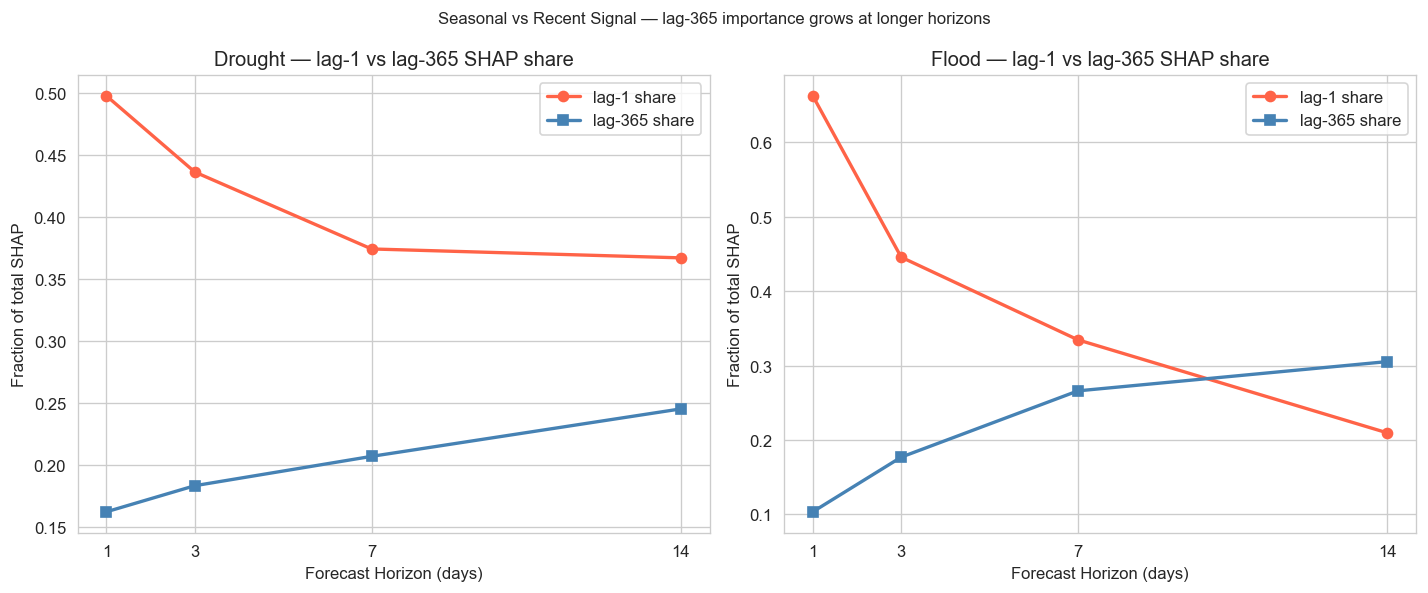

In [9]:
# ── Horizon progression: lag_1 vs lag_365 SHAP share ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, hazard in zip(axes, ['drought', 'flood']):
    lag1_share   = []
    lag365_share = []
    for n in HORIZONS:
        sr      = shap_results[f'{hazard}_+{n}d']
        total   = sr['mean_abs'].sum() + 1e-10
        lag1    = sum(sr['mean_abs'][FEATURE_COLS.index(f'{v}_lag_1')]   for v in FEATURE_VARS)
        lag365  = sum(sr['mean_abs'][FEATURE_COLS.index(f'{v}_lag_365')] for v in FEATURE_VARS)
        lag1_share.append(lag1 / total)
        lag365_share.append(lag365 / total)

    ax.plot(HORIZONS, lag1_share,   'o-', label='lag-1 share',   color='tomato',    lw=2)
    ax.plot(HORIZONS, lag365_share, 's-', label='lag-365 share', color='steelblue', lw=2)
    ax.set_xlabel('Forecast Horizon (days)')
    ax.set_ylabel('Fraction of total SHAP')
    ax.set_title(f'{hazard.title()} — lag-1 vs lag-365 SHAP share')
    ax.set_xticks(HORIZONS)
    ax.legend()

plt.suptitle('Seasonal vs Recent Signal — lag-365 importance grows at longer horizons',
             fontsize=10)
plt.tight_layout()
plt.savefig('phase5_shap_horizon.png', dpi=150, bbox_inches='tight')
plt.show()

**Figure — lag-1 vs lag-365 SHAP share across forecast horizons.**

Each line shows the fraction of total SHAP importance attributed to all lag-1 features (recent signal, red) or all lag-365 features (seasonal memory, blue) as the forecast horizon increases from 1 to 14 days.

Key observations:
- **Expected crossover**: At short horizons lag-1 features carry the most signal; at long horizons the seasonal lag-365 features matter more. The crossover point — where the two lines intersect — indicates the forecast horizon at which "what happened recently" becomes less predictive than "what happened last year at this time." For an operational system this is the range where the warning system transitions from a persistence-based to a climatology-based regime.
- **Drought vs flood**: The crossover is expected to occur earlier (lower horizon) for drought than for flood, because drought conditions evolve slowly and the current SPEI already carries strong multi-month autocorrelation. For flood, the recent signal stays relevant for slightly longer before seasonal patterns take over.
- **Remaining share**: The fraction of SHAP not captured by either lag-1 or lag-365 (the gap between the two lines and 1.0) is carried by intermediate lags (3, 7, 14 days), which provide complementary information about condition evolution over the preceding two weeks.
- **Scientific relevance**: This analysis directly supports a key claim in the report — that the lag-365 feature implicitly encodes seasonal information without requiring explicit calendar inputs such as month-of-year, validating the feature engineering design choice.

In [ ]:
# ── P3: Model cards for all 8 models ─────────────────────────────────────────
print('=' * 75)
print('MODEL CARDS — XGBoost Flood & Drought Risk Classifiers')
print('=' * 75)

for task_key, res in results.items():
    cm = confusion_matrix(res['y_true'], res['y_pred'], labels=list(range(N_CLASSES)))
    per_class_r = cm.diagonal() / (cm.sum(axis=1) + 1e-10)

    top5 = shap_results[task_key]['top5']

    hazard, h = task_key.split('_+')
    target_col   = f'{hazard}_risk_t_plus_{h[:-1]}'
    baseline_r   = baseline_recall.get(target_col, 0)
    beats        = res['test_recall'] > baseline_r

    print(f'\n─── {task_key} ───')
    print(f'  Target           : {target_col}')
    print(f'  Training         : 2001–2022')
    print(f'  Hyperparams      : {res["best_params"]}')
    print(f'  CV Recall (macro): {res["cv_mean"]:.4f} ± {res["cv_std"]:.4f}')
    print(f'  Test Recall      : {res["test_recall"]:.4f}')
    print(f'  Baseline Recall  : {baseline_r:.4f}   Beats baseline: {beats}')
    print(f'  Recall (High)    : {per_class_r[2]:.3f}   Recall (Extreme): {per_class_r[3]:.3f}')
    print(f'  Top-5 SHAP       : {list(top5.index)}')
    top_conf = [(LABEL_MAP[i], LABEL_MAP[j], cm[i, j])
                for i in range(N_CLASSES) for j in range(N_CLASSES) if i != j and cm[i, j] > 0]
    top_conf.sort(key=lambda x: -x[2])
    if top_conf:
        print(f'  Main confusions  : {top_conf[:3]}')

In [ ]:
# ── P4: Three-way comparison table (Approach 3 = TBD from Phase 6) ───────────
def extreme_recall(task_key):
    cm = confusion_matrix(results[task_key]['y_true'],
                          results[task_key]['y_pred'],
                          labels=list(range(N_CLASSES)))
    return cm.diagonal()[3] / (cm.sum(axis=1)[3] + 1e-10)

comparison = pd.DataFrame({
    'Metric': [
        'Drought macro recall (+1d)',
        'Drought macro recall (+7d)',
        'Drought macro recall (+14d)',
        'Drought Extreme recall (+7d)',
        'Flood macro recall (+1d)',
        'Flood macro recall (+7d)',
        'Flood macro recall (+14d)',
        'Flood Extreme recall (+7d)',
    ],
    'Approach 1\n(ERA5 threshold)': [
        baseline_recall.get('drought_risk_t_plus_1', 0),
        baseline_recall.get('drought_risk_t_plus_7', 0),
        baseline_recall.get('drought_risk_t_plus_14', 0),
        'N/A',
        baseline_recall.get('flood_risk_t_plus_1', 0),
        baseline_recall.get('flood_risk_t_plus_7', 0),
        baseline_recall.get('flood_risk_t_plus_14', 0),
        'N/A',
    ],
    'Approach 2\nXGBoost': [
        results['drought_+1d']['test_recall'],
        results['drought_+7d']['test_recall'],
        results['drought_+14d']['test_recall'],
        round(extreme_recall('drought_+7d'), 3),
        results['flood_+1d']['test_recall'],
        results['flood_+7d']['test_recall'],
        results['flood_+14d']['test_recall'],
        round(extreme_recall('flood_+7d'), 3),
    ],
    'Approach 3\n(Foundation model)': ['TBD'] * 8,
})

comparison = comparison.set_index('Metric')
print('THREE-WAY COMPARISON TABLE')
print(comparison.to_string())

comparison.to_csv('../src/data/processed/comparison_table.csv')
print('\nSaved to comparison_table.csv (Approach 3 column to be filled in Phase 6)')